# Bootcamp Final Quiz

**Time Limit:** 60 minutes  
**Total Points:** 100  
**Format:** Open Internet — you may use Google, Stack Overflow, documentation, etc.  

---

### Rules
1. All code cells **must run without errors** when submitted
2. Write your markdown/text answers in the designated cells
3. Do **not** modify the Setup cell below
4. Questions build on each other — complete them in order
5. Read each question carefully before answering

### Grading Breakdown
| Section | Topic | Points |
|---------|-------|--------|
| 1 | Concepts & Warm-Up | 15 |
| 2 | Linear Regression & Metrics | 15 |
| 3 | Logistic Regression & Classification | 25 |
| 4 | Tree-Based Models | 25 |
| 5 | Model Pipeline & Deployment | 10 |
| 6 | Boss Level — End-to-End Challenge | 10 |
| **Total** | | **100** |

**Good luck!**

In [1]:
# ============================================================
# SETUP CELL — DO NOT MODIFY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    auc,
)
from sklearn.datasets import make_classification
import joblib

# Load datasets
heart_df = pd.read_csv("data/heart.csv")
social_df = pd.read_csv("data/Social_Network_Ads.csv")

print(f"heart_df: {heart_df.shape[0]} rows, {heart_df.shape[1]} columns")
print(f"social_df: {social_df.shape[0]} rows, {social_df.shape[1]} columns")
print("\n✅ Setup complete — you're ready to go!")

heart_df: 289 rows, 14 columns
social_df: 400 rows, 5 columns

✅ Setup complete — you're ready to go!


---
## Section 1: Concepts & Warm-Up (15 pts)
*Estimated time: ~10 minutes*

---

### Q1 — Multi-Class vs Multi-Label (3 pts)

Consider these two scenarios:

- **Scenario A:** A model that classifies an email into **exactly one** category: Primary, Social, or Promotions.
- **Scenario B:** A model that tags a news article with **one or more** topics: Politics, Sports, Technology, Entertainment.

**Tasks:**
1. Which scenario is multi-class? Which is multi-label? (1 pt)
2. Give **one real-world example** of each that is NOT listed above. (2 pts)

*✏️ Your answer here:*
1. Scenario A is Multi-Label and Scenario B is Multi-Class

2. Scenario B -> A model that identifies multiple objects in the picture like road, car, signal etc
   Scenario A -> A model that classifies picture into cat, or dog


### Q2 — Bias-Variance Tradeoff (4 pts)

Two students trained a `RandomForestRegressor` on the same dataset with different `max_depth` settings. Here are their results:

| Model | max_depth | Train MSE (normalized) | Test MSE (normalized) |
|-------|-----------|----------------------|---------------------|
| Model A | 3 | 0.52 | 0.82 |
| Model B | 20 | 0.02 | 0.95 |

**Tasks:**
1. Which model is **underfitting**? Which is **overfitting**? Explain how you can tell from the numbers. (2 pts)
2. What is **bias** and what is **variance** in the context of these models? (1 pt)
3. What `max_depth` range would you experiment with next, and why? (1 pt)

*✏️ Your answer here:*
1. Model B is overfitting since really low MSE on Train Dataset but high MSE on Test Dataset.
   Model A can be classified with underfitting since max_depth is set as 3. We might be able to get signal from Training Data changing max_depth 
2. max_depth is parameter which adjusts RandomForestRegressor's training behavior. If we set max_depth as 3, when RandomForestRegressor fit with train dataset it goes maximum 3 levels/hierarchies 
3. From 5 to 10 based on above result  

### Q3 — Encoding Categorical Variables (4 pts)

The `social_df` has a `Gender` column with values `Male` and `Female`.

**Tasks:**
1. In a markdown cell below, explain the difference between **Label Encoding** and **One-Hot Encoding**. When would you prefer one over the other? (2 pts)
2. Write code to create a one-hot encoded version of `Gender` and add it to the DataFrame. Print the first 5 rows showing the new columns. (2 pts)

*✏️ Your explanation here:*

1. 
- One-Hot Encoding convert categorical data to 0 and 1 matrix. (ex. Yellow, Blue, Red) -> if Yellow, Yellow: 1, Blue: 0, Red: 0
- Label Encoding convert categorical data to 0 to n -1. (ex. Yellow, Blue, Red) -> Yellow: 0, Blue: 1, Red: 2 -> if Yellow, Yellow: 0

2. 
- one_hot_encoding = pd.get_dummies(social_df['Gender']) -> One-Hot Encoding
- df_combined = pd.concat([social_df, one_hot_encoding], axis=1) -> Combined 

In [2]:
# Q3 — Your code here
#print(social_df.dtypes)
one_hot_encoding = pd.get_dummies(social_df['Gender'])
#print(one_hot_encoding)
df_combined = pd.concat([social_df, one_hot_encoding], axis=1)
df_combined.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Female,Male
0,15624510,Male,19,19000,0,False,True
1,15810944,Male,35,20000,0,False,True
2,15668575,Female,26,43000,0,True,False
3,15603246,Female,27,57000,0,True,False
4,15804002,Male,19,76000,0,False,True


### Q4 — Train-Test Split (4 pts)

Prepare the `heart_df` dataset for modeling.

**Tasks:**
1. Separate features (`X`) and target (`y`) — the target column is `"target"` (2 pts)
2. Perform an **80/20** train-test split with `random_state=42` (1 pt)
3. Print the shape of `X_train`, `X_test`, `y_train`, `y_test` (1 pt)

**⚠️ Store the results as `X_train, X_test, y_train, y_test` — you will reuse these in later sections!**

In [3]:
# Q4 — Your code here

# 1
#print(heart_df.info())
X = heart_df.drop(columns=('output'))
#print(X)
heart_df['target'] = heart_df['output']
y = heart_df['target']
#print(y)

#2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3
print(f"""
X_train.shape: {X_train.shape}
X_test.shape: {X_test.shape}
y_train.shape: {y_train.shape}
y_test.shape: {y_test.shape}
""")


X_train.shape: (231, 13)
X_test.shape: (58, 13)
y_train.shape: (231,)
y_test.shape: (58,)



---
## Section 2: Linear Regression & Metrics (15 pts)
*Estimated time: ~10 minutes*

---

### Q5 — Bug Hunt: Gradient Descent (5 pts)

The code below implements gradient descent to fit a line predicting `thalach` (max heart rate) from `age` using the heart dataset. **But it has 3 bugs!**

**Tasks:**
1. Find and fix all **3 bugs** (3 pts)
2. Add a comment next to each fix explaining what was wrong (1 pt)
3. After fixing, the MSE should decrease over iterations. Print the final MSE. (1 pt)

Final MSE: 0.0000


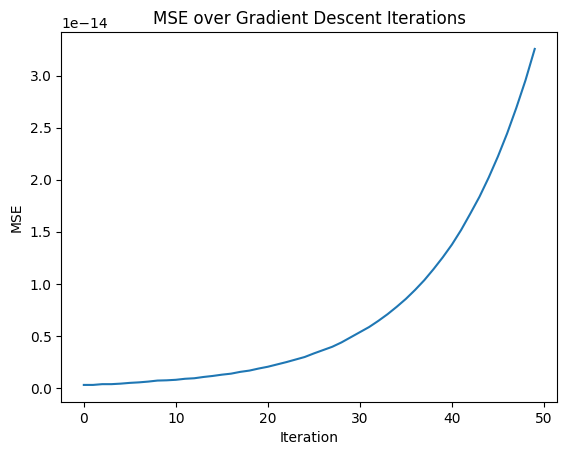

In [4]:
# Q5 — Find and fix the 3 bugs in this gradient descent implementation
# Data preparation
gd_X = heart_df["age"].values.astype(float)
gd_y = heart_df["thalachh"].values.astype(float) 
#gd_y = heart_df["thalach"].values.astype(float) -> typo 

# Normalize
gd_X = (gd_X - gd_X.mean()) / gd_X.std()
gd_y = (gd_y - gd_y.mean()) / gd_y.std()

# Initialize parameters
theta_0, theta_1 = 0.0, 0.0
learning_rate = 0.1
num_iterations = 50

mse_history = []

for iteration in range(num_iterations):
    # Predict
    y_pred = theta_0 + theta_1 * gd_X

    # Compute errors
    errors = gd_y - y_pred

    # BUG 1 is somewhere in the MSE calculation
    mse = np.mean(errors)
    mse_history.append(mse)

    # BUG 2 is somewhere in the theta_0 update
    theta_0 = theta_0 - learning_rate * np.mean(errors)

    # BUG 3 is somewhere in the theta_1 update
    theta_1 = theta_1 + learning_rate * np.mean(errors)

print(f"Final MSE: {mse_history[-1]:.4f}")
plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE over Gradient Descent Iterations")
plt.show()

### Q6 — MAE vs MSE: Manual Computation (5 pts)

Using the `heart_df`, fit a `LinearRegression` to predict `thalach` (max heart rate) from `age`.

**Tasks:**
1. Fit the model on the full `heart_df` (1 pt)
2. Compute **MAE** manually (without sklearn): `np.mean(np.abs(y - y_pred))` (1 pt)
3. Compute **MSE** manually (without sklearn): `np.mean((y - y_pred) ** 2)` (1 pt)
4. Print both values (1 pt)
5. Answer in markdown: *"If one patient had an actual max heart rate of 200 but the model predicted 100, which metric (MAE or MSE) would be more affected by this single outlier, and why?"* (1 pt)

In [5]:
# Q6 — Your code here

#1
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#2
mae = np.mean(np.abs(y_test - y_pred))

#3
mse = np.mean((y_test - y_pred) ** 2)

#4
print(f'mae: {mae}')
print(f'mse: {mse}')

mae: 0.28758027003966674
mse: 0.12414794706828508


*✏️ Your outlier answer here:*

MSE is more affected by outlier since MSE square difference(error)


### Q7 — Z-Score Normalization (5 pts)

**Tasks:**
1. Apply z-score normalization to `thalach`: `(thalach - mean) / std` (2 pts)
2. Fit a `LinearRegression` on `age` (raw, not normalized) vs `thalach` (normalized) (1 pt)
3. Print the model's `coef_` and `intercept_` (1 pt)
4. In markdown: what does the `intercept_` represent when the target is normalized? (1 pt)

In [6]:
# Q7 — Your code here

#1
from sklearn.preprocessing import StandardScaler
#print(heart_df.info())
scaler = StandardScaler()
heart_df['normalized_thalach'] = scaler.fit_transform(heart_df[['thalachh']])
#print(heart_df['normalized_thalach'].head())
X = heart_df[['age']]
y = heart_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2 
heart_model = LinearRegression()
heart_model.fit(X_train, y_train)

#3
print(f'Age not normalized')
print(f'coef_: {heart_model.coef_}')
print(f'intercept_: {heart_model.intercept_}')

X = heart_df[['normalized_thalach']]
y = heart_df['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

heart_model = LinearRegression()
heart_model.fit(X_train, y_train)
print("=============================================")
#3
print(f'normalized_thalach')
print(f'coef_: {heart_model.coef_}')
print(f'intercept_: {heart_model.intercept_}')

Age not normalized
coef_: [-0.00941773]
intercept_: 1.0874618911159053
normalized_thalach
coef_: [0.19776809]
intercept_: 0.5778227789900567


*✏️ Your intercept answer here:*

If Normalized data is standarized, it is more easy to compare result with other model


---
## Section 3: Logistic Regression & Classification Metrics (25 pts)
*Estimated time: ~12 minutes*

---

### Q8 — Logistic Regression with Two Features (4 pts)

In class, we trained a `LogisticRegression` on `social_df` using **only Age**. Now let's try both features.

**Tasks:**
1. Use **both** `Age` AND `EstimatedSalary` as features, `Purchased` as target (1 pt)
2. Train-test split: 80/20, `random_state=42` (1 pt)
3. Train a `LogisticRegression` and print the `classification_report` on the **test** set (1 pt)
4. In markdown: does adding `EstimatedSalary` improve results compared to using only `Age`? Why might that be? (1 pt)

**⚠️ Store your social network variables as `social_X_train, social_X_test, social_y_train, social_y_test` and the model as `social_model` — used in Q9-Q11.**

In [7]:
# Q8 — Your code here
#print(social_df.info())

X = social_df[['Age']]
y = social_df['Purchased']
#print(X.head())
#print(y.head())
social_X_train, social_X_test, social_y_train, social_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

social_model = LogisticRegression()
social_model.fit(social_X_train, social_y_train)

social_y_pred = social_model.predict(social_X_test)

print(f""" Only Age
{classification_report(social_y_test, social_y_pred)}""")

#1
X = social_df[['Age', 'EstimatedSalary']]
y = social_df['Purchased']
#print(X.head())
#print(y.head())

#2
social_X_train, social_X_test, social_y_train, social_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3
social_model = LogisticRegression()
social_model.fit(social_X_train, social_y_train)
social_y_pred = social_model.predict(social_X_test)

print(f""" Age + EstimatedSalary
{classification_report(social_y_test, social_y_pred)}""")

 Only Age
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        52
           1       0.92      0.82      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.89      0.90        80
weighted avg       0.91      0.91      0.91        80

 Age + EstimatedSalary
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



*✏️ Your comparison answer here:*

Adding Estimated Salary seems not improve results.  

### Q9 — Manual Confusion Matrix (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predictions on the test set (1 pt)
2. Manually compute **TP, TN, FP, FN** using the boolean indexing pattern from class (2 pts):  
   `tp = y_test[(y_test == 1) & (y_pred == 1)].sum()`
3. Manually compute **precision** and **recall** from your TP/TN/FP/FN values (1 pt)
4. Verify your manual values match `precision_score()` and `recall_score()` from sklearn — print both to confirm (1 pt)

In [8]:
# Q9 — Your code here
#precision = tp/(tp+fp)
#recall = tp/(tp+fp)

#1
social_y_pred = social_model.predict(social_X_test)

# 2,3,4
print("Positive Side(Purchased 1) of information")
tp = social_y_test[(social_y_test == 1) & (social_y_pred == 1)].count()
tn = social_y_test[(social_y_test == 0) & (social_y_pred == 0)].count()
fp = social_y_test[(social_y_test == 0) & (social_y_pred == 1)].count()
fn = social_y_test[(social_y_test == 1) & (social_y_pred == 0)].count()
print(f""" summary of count
tp: {tp}
tn: {tn}
fp: {fp}
fn: {fn}
precision = tp/(tp+fp): {tp / (tp +fp)}
recall = tp/(tp+fp): {tp / (tp + fn)}
=precision_score=
{precision_score(social_y_test, social_y_pred)}
=recall_score=
{recall_score(social_y_test, social_y_pred)}
""")

#2,3,4
print("Negative Side(Not Purchased 0) of information")
tp = social_y_test[(social_y_test == 0) & (social_y_pred == 0)].count()
tn = social_y_test[(social_y_test == 1) & (social_y_pred == 1)].count()
fp = social_y_test[(social_y_test == 1) & (social_y_pred == 0)].count()
fn = social_y_test[(social_y_test == 0) & (social_y_pred == 1)].count()
print(f""" summary of count
tp: {tp}
tn: {tn}
fp: {fp}
fn: {fn}
precision = tp/(tp+fp): {tp / (tp +fp)}
recall = tp/(tp+fp): {tp / (tp + fn)}
=precision_score=
{precision_score(social_y_test, social_y_pred,pos_label=0)}
=recall_score=
{recall_score(social_y_test, social_y_pred,pos_label=0)}
""")

# Verification
#precision_score
#recall_score
#print(classification_report(social_y_test, social_y_pred))


Positive Side(Purchased 1) of information
 summary of count
tp: 21
tn: 50
fp: 2
fn: 7
precision = tp/(tp+fp): 0.9130434782608695
recall = tp/(tp+fp): 0.75
=precision_score=
0.9130434782608695
=recall_score=
0.75

Negative Side(Not Purchased 0) of information
 summary of count
tp: 50
tn: 21
fp: 7
fn: 2
precision = tp/(tp+fp): 0.8771929824561403
recall = tp/(tp+fp): 0.9615384615384616
=precision_score=
0.8771929824561403
=recall_score=
0.9615384615384616



### Q10 — Threshold Tuning (6 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predicted probabilities using `predict_proba()` — use the **positive class** column (1 pt)
2. Sweep thresholds from **0.0 to 1.0** in steps of **0.05** (1 pt)
3. For each threshold, convert probabilities to predictions using: `[1 if p >= threshold else 0 for p in probs]` (1 pt)
4. Compute precision and recall at each threshold (1 pt)
5. Plot **precision** and **recall** as two lines against threshold (1 pt)
6. In markdown: At approximately what threshold do precision and recall cross? What does this crossing point mean for the Social Network Ads business case? (1 pt)

In [9]:
# Q10 — Your code here

#1
predicted_probabilities = social_model.predict_proba(social_X_test)
#print(predicted_probabilities)
#social_y_pred

#2,3,4
print("Positive side")
for i in np.arange(0, 1.0, 0.05):
    example_pred = [1 if prob[1] >= i else 0 for prob in predicted_probabilities]
    print(
        f"Threshold: {i:.2f} | Precision: {precision_score(social_y_test, example_pred):.2f} | Recall: {recall_score(social_y_test, example_pred):.2f}"
    )

Positive side
Threshold: 0.00 | Precision: 0.35 | Recall: 1.00
Threshold: 0.05 | Precision: 0.48 | Recall: 1.00
Threshold: 0.10 | Precision: 0.58 | Recall: 1.00
Threshold: 0.15 | Precision: 0.68 | Recall: 1.00
Threshold: 0.20 | Precision: 0.72 | Recall: 1.00
Threshold: 0.25 | Precision: 0.76 | Recall: 1.00
Threshold: 0.30 | Precision: 0.81 | Recall: 0.89
Threshold: 0.35 | Precision: 0.80 | Recall: 0.86
Threshold: 0.40 | Precision: 0.85 | Recall: 0.82
Threshold: 0.45 | Precision: 0.91 | Recall: 0.75
Threshold: 0.50 | Precision: 0.91 | Recall: 0.75
Threshold: 0.55 | Precision: 0.95 | Recall: 0.68
Threshold: 0.60 | Precision: 0.95 | Recall: 0.68
Threshold: 0.65 | Precision: 0.95 | Recall: 0.64
Threshold: 0.70 | Precision: 1.00 | Recall: 0.50
Threshold: 0.75 | Precision: 1.00 | Recall: 0.50
Threshold: 0.80 | Precision: 1.00 | Recall: 0.46
Threshold: 0.85 | Precision: 1.00 | Recall: 0.46
Threshold: 0.90 | Precision: 1.00 | Recall: 0.39
Threshold: 0.95 | Precision: 1.00 | Recall: 0.25


In [10]:
#2,3,4,
print("Negative side")
predicted_probabilities = social_model.predict_proba(social_X_test)
#print(predicted_probabilities)
#social_y_pred
for i in np.arange(0, 1.0, 0.05):
    example_pred = [1 if prob[0] <= i else 0 for prob in predicted_probabilities]
    print(
        f"Threshold: {i:.2f} | Precision: {precision_score(social_y_test, example_pred,pos_label=0):.2f} | Recall: {recall_score(social_y_test, example_pred,pos_label=0):.2f}"
    )


Negative side
Threshold: 0.00 | Precision: 0.65 | Recall: 1.00
Threshold: 0.05 | Precision: 0.71 | Recall: 1.00
Threshold: 0.10 | Precision: 0.75 | Recall: 1.00
Threshold: 0.15 | Precision: 0.78 | Recall: 1.00
Threshold: 0.20 | Precision: 0.78 | Recall: 1.00
Threshold: 0.25 | Precision: 0.79 | Recall: 1.00
Threshold: 0.30 | Precision: 0.79 | Recall: 1.00
Threshold: 0.35 | Precision: 0.84 | Recall: 0.98
Threshold: 0.40 | Precision: 0.85 | Recall: 0.98
Threshold: 0.45 | Precision: 0.85 | Recall: 0.98
Threshold: 0.50 | Precision: 0.88 | Recall: 0.96
Threshold: 0.55 | Precision: 0.88 | Recall: 0.96
Threshold: 0.60 | Precision: 0.91 | Recall: 0.92
Threshold: 0.65 | Precision: 0.92 | Recall: 0.88
Threshold: 0.70 | Precision: 0.94 | Recall: 0.88
Threshold: 0.75 | Precision: 1.00 | Recall: 0.83
Threshold: 0.80 | Precision: 1.00 | Recall: 0.79
Threshold: 0.85 | Precision: 1.00 | Recall: 0.75
Threshold: 0.90 | Precision: 1.00 | Recall: 0.62
Threshold: 0.95 | Precision: 1.00 | Recall: 0.42


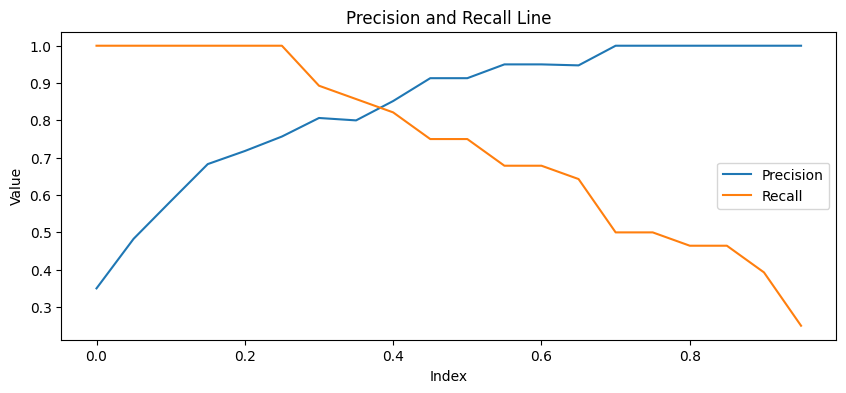

In [11]:
#6
predicted_probabilities = social_model.predict_proba(social_X_test)
#print(predicted_probabilities)
#social_y_pred
results=[]
for i in np.arange(0, 1.0, 0.05):
    example_pred = [1 if prob[1] >= i else 0 for prob in predicted_probabilities]
    results.append({'threshold': i, 'precision': precision_score(social_y_test, example_pred), 'recall': recall_score(social_y_test, example_pred)})
    #results.append({'threshold': i,'precision': precision_score(social_y_test, expample_pred),'recall': recall_score(social_y_test, example_pred)})
#print(results)
thre_precision_recall = pd.DataFrame(results)
thre_precision_recall = thre_precision_recall.set_index('threshold')
thre_precision_recall.head()

#thre_precision_recall.plot(y=['precision', 'recall'], kind='line', title='Precision and Recall Line')
import matplotlib.pyplot as plt

# assuming thre_precision_recall is your DataFrame
fig, axes = plt.subplots(nrows=1, figsize=(10, 4))
axes.plot(thre_precision_recall['precision'], label='Precision')
axes.plot(thre_precision_recall['recall'], label='Recall')
axes.set_title('Precision and Recall Line')
axes.set_xlabel('Index')  # or any other column if you want to plot against a specific column
axes.set_ylabel('Value')
axes.legend()
plt.show()

*✏️ Your threshold analysis here:*

Around threshold 0.4, this point shows both Precision and Recall is balanced

### Q11 — Precision-Recall Curve & AUC (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Compute the precision-recall curve using `precision_recall_curve()` from sklearn (1 pt)
2. Compute the **AUC** (Area Under Curve) using `auc(recall, precision)` (1 pt)
3. Compute the **no-skill baseline**: `len(y_test[y_test == 1]) / len(y_test)` (1 pt)
4. Plot the PR curve with the no-skill baseline as a horizontal dashed line. Include labels and a legend. (1 pt)
5. In markdown: what does a higher AUC value tell you about your model? What would an AUC of 0.5 mean? (1 pt)

1.0


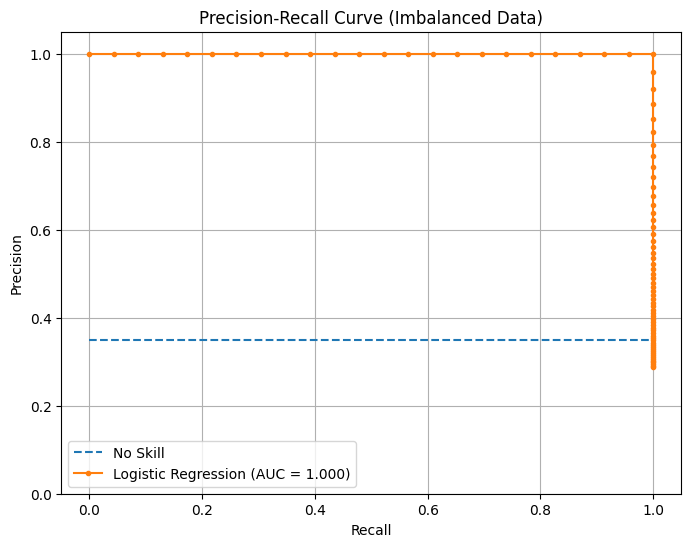

In [12]:
# Q11 — Your code here
#1
lr_probs = social_model.predict_proba(social_X_test)
lr_probs = lr_probs[:, 1]

precision, recall, _ = precision_recall_curve(social_y_pred, lr_probs)
#print(precision,recall)

#2
# Calculate AUC
lr_auc = auc(recall, precision)
print(lr_auc)

#3
no_skill = len(social_y_test[social_y_test == 1]) / len(social_y_test)

#4
# Plot the curve
plt.figure(figsize=(8, 6))

plt.plot([0, 1], [no_skill, no_skill], linestyle="--", label="No Skill")

# Plot the model curve
plt.plot(
    recall, precision, marker=".", label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

# Labels and Title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Imbalanced Data)")
plt.legend()
plt.grid(True)
plt.ylim([0.0, 1.05])

plt.show()

*✏️ Your AUC analysis here:*

Interpretation of AUC Values:
- 1.0: Perfect classification/discrimination.
- 0.90 – 0.99: Outstanding or very good performance.
- 0.80 – 0.89: Good or acceptable performance.
- 0.70 – 0.79: Moderate or acceptable.
- 0.50 – 0.69: Poor or no discrimination (near random).
- < 0.50: Indicative of a flawed model (similar to a coin flip or worse). 

### Q12 — The Hospital Dilemma (5 pts)

A hospital builds a model to predict **heart disease** using the `heart_df` dataset. The model achieves:
- **Precision: 95%**
- **Recall: 60%**

The hospital administrator says:  
> *"This is great! When we say someone has heart disease, we're right 95% of the time."*

A doctor disagrees and says the model is **dangerous**.

**Tasks:**
1. Who is correct — the administrator or the doctor? Explain your reasoning. (2 pts)
2. What does 60% recall **actually mean** in terms of real patients? How many sick patients are being missed? (1 pt)
3. Which metric matters more for this use case — precision or recall? Why? (1 pt)
4. Name **one concrete action** you would take to improve recall (e.g., threshold adjustment, more data, different model). (1 pt)

*✏️ Your answer here:*

1. Doctor is correct. Recall 60% means it only catches 60% of true heart disease patients and misses 40% of them. Heart disease is a serious disease so Recall is more important than Precision.
2. It misses 40% of true heart disease patients
3. Recall matters since misses lead patients' death
4. Threshold adjustment helps to optimize model prediction

---
## Section 4: Tree-Based Models (25 pts)
*Estimated time: ~12 minutes*

---

### Q13 — Decision Tree Visualization & Feature Importance (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `DecisionTreeClassifier` with `max_depth=3` and `random_state=42` (1 pt)
2. Visualize the tree using `plot_tree()` with `filled=True`, `feature_names`, and `class_names=["No Disease", "Disease"]` (2 pts)
3. Print `feature_importances_` as a pandas Series, sorted from highest to lowest (2 pts)
4. In markdown: which feature is the most important? Does this make intuitive medical sense? (1 pt)

In [13]:
# Q13 — Your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#print(heart_df.info())
X = heart_df.drop(columns=['output','target'])
y = heart_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#1
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
dt_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

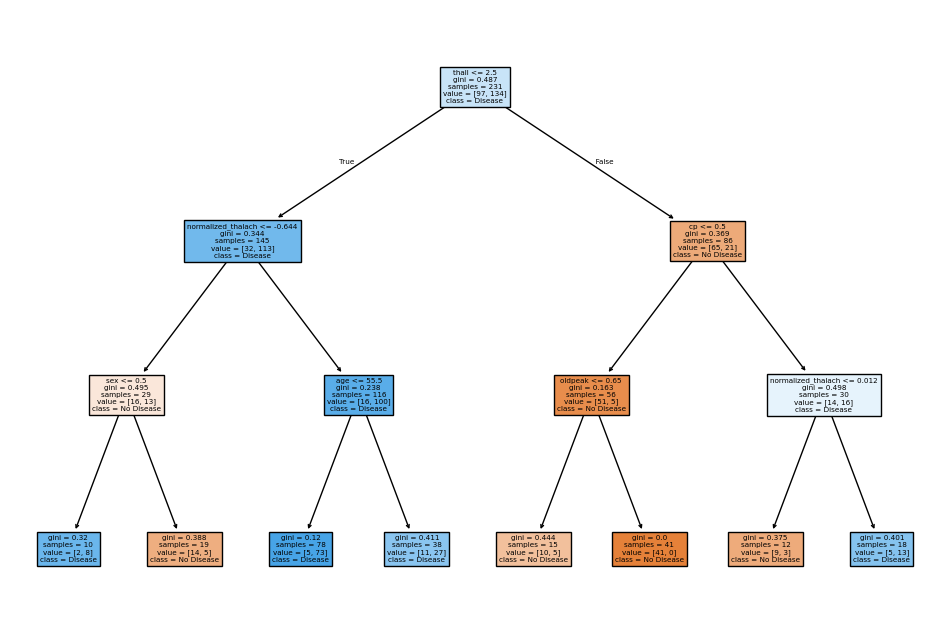

In [14]:
#2
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["No Disease","Disease"])
plt.show()

In [15]:
#3
importances = dt_model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

feature_names = X.columns
print("Top 10 Features (NumPy):")
for i in range(10):
    idx = sorted_indices[i]
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# Display bottom 10 features and their importances
# The last 10 indices of the sorted array correspond to the bottom 10 features
print("\nBottom 10 Features (NumPy):")
for i in range(1, 11):
    idx = sorted_indices[-i]
    print(f"{len(feature_names) - i + 1}. {feature_names[idx]}: {importances[idx]:.4f}")



Top 10 Features (NumPy):
1. thall: 0.5277
2. normalized_thalach: 0.1904
3. cp: 0.1315
4. sex: 0.0645
5. age: 0.0443
6. oldpeak: 0.0417
7. caa: 0.0000
8. slp: 0.0000
9. exng: 0.0000
10. thalachh: 0.0000

Bottom 10 Features (NumPy):
14. trtbps: 0.0000
13. chol: 0.0000
12. fbs: 0.0000
11. restecg: 0.0000
10. thalachh: 0.0000
9. exng: 0.0000
8. slp: 0.0000
7. caa: 0.0000
6. oldpeak: 0.0417
5. age: 0.0443


*✏️ Your feature importance analysis here:*

Based on thall definition 
- thall -> Thallium Stress Test result.  It is a categorical variable that indicates the heart's blood flow efficiency, specifically identifying blood flow defects.

It(thall) shows the heart's blood flow efficiency. This seems to be intuitive medical sense

### Q14 — predict vs predict_proba (6 pts)

Using the decision tree from Q13:

**Tasks:**
1. Create a DataFrame with the following columns for the **first 10 test samples** (3 pts):
   - `Actual` — true labels from `y_test`
   - `Predicted` — model predictions
   - `Prob_No_Disease` — probability of class 0
   - `Prob_Disease` — probability of class 1
2. Display the DataFrame (1 pt)
3. Find the sample where the model is **least confident** (probability closest to 0.5). Print its index and probabilities. (1 pt)
4. In markdown: what does it mean when `predict_proba` gives [0.5, 0.5]? How does the decision tree produce these probabilities? (1 pt)

In [16]:
# Q14 — Your code here

#1
samples = X_test[0:10] 
Actual = y_test[0:10].to_numpy()
#print(Actual)
Predicted = dt_model.predict(samples)
#print(predicted)
Predicted_probabilities = dt_model.predict_proba(samples)
Prob_No_Disease = predicted_probabilities[:, 0]
Prob_Disease = predicted_probabilities[:, 1]

results = []
for i in range(0,10):
    results.append({'Actual': Actual[i], 'Predicted': Predicted[i], 'Prob_No_Disease': Prob_No_Disease[i], 'Prob_Disease': Prob_Disease[i]})

df_samples = pd.DataFrame(results)

In [17]:
#2
df_samples.head()

,Actual,Predicted,Prob_No_Disease,Prob_Disease
0,1,1,0.743367,0.256633
1,1,1,0.018328,0.981672
2,0,0,0.982418,0.017582
3,1,1,0.121434,0.878566
4,0,0,0.987670,0.012330


In [18]:
#3
target_value = 0.5
closest_index = (df_samples['Prob_Disease'] - target_value).abs().idxmin()
closest_value = df_samples.loc[closest_index]
print(closest_value)

Actual             0.000000
Predicted          0.000000
Prob_No_Disease    0.591064
Prob_Disease       0.408936
Name: 9, dtype: float64


*✏️ Your predict_proba explanation here:*

Based on Dicision criteria, it can not put any favor for specific class


### Q15 — Ensemble Showdown: DT vs RF vs GB (7 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train all three models (3 pts):
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(n_estimators=20, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=20, random_state=42)`
2. Print the **test accuracy** for each model using `accuracy_score` (1 pt)
3. Create a **bar plot** comparing the three accuracies (1 pt)
4. In markdown, answer BOTH: (2 pts)
   - What is **bagging** and how does Random Forest use it?
   - What is the key difference between **bagging** (Random Forest) and **boosting** (Gradient Boosting)?

In [19]:
# Q15 — Your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

#print(heart_df.info())
X = heart_df.drop(columns=('output') )
y = heart_df['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#1
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb.fit(X_train, y_train)

dt_y_pred_test = dt.predict(X_test)
rf_y_pred_test = rf.predict(X_test)
gb_y_pred_test = gb.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_y_pred_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred_test)
gb_accuracy = accuracy_score(y_test, gb_y_pred_test)

#2
print(f"Decision Tree accuracy: {dt_accuracy:.2f}")
print(f"Random Forest accuracy: {rf_accuracy:.2f}")
print(f"Gradient Boosting accuracy: {gb_accuracy:.2f}")

Decision Tree accuracy: 1.00
Random Forest accuracy: 1.00
Gradient Boosting accuracy: 1.00


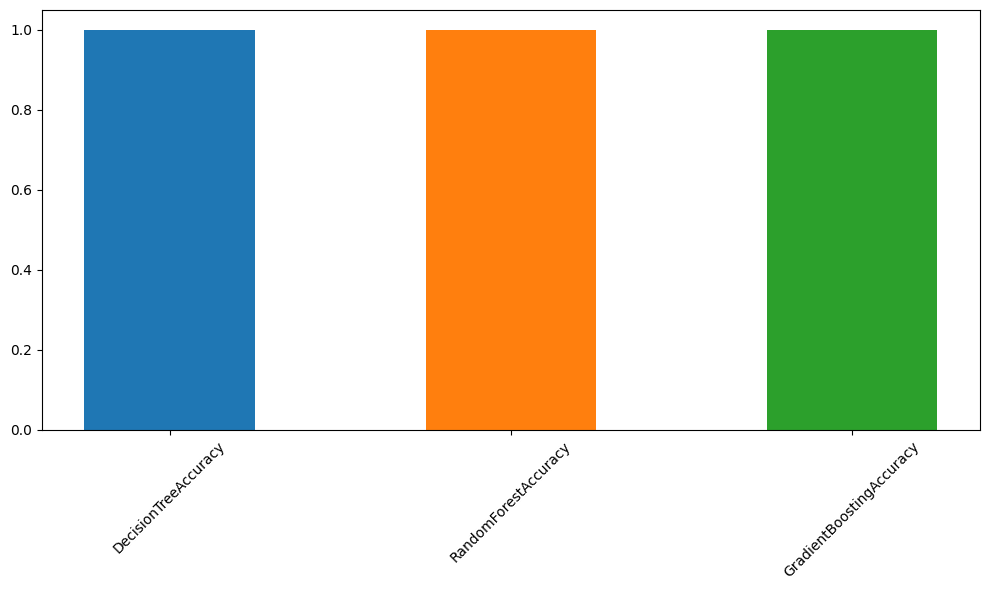

In [20]:
#3
df_graph = pd.DataFrame([{"DecisionTreeAccuracy": dt_accuracy, "RandomForestAccuracy": rf_accuracy, "GradientBoostingAccuracy": gb_accuracy}])
#df_graph.plot(kind='bar',xlabel='',xticks=[])

# Define bar positions
bar_width = 0.5
x = np.arange(len(df_graph.columns))
x = x * 1  # Add space between the bars
# Plot using matplotlib
plt.figure(figsize=(10,6))  # Set the figure size
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
plt.bar(x, df_graph.iloc[0], width=bar_width, color=colors)  # Plot the bars
# Set xticks at the bar positions
plt.xticks(x, df_graph.columns, rotation=45)  # Label the bars
plt.xlabel('')  # Remove x-axis label
plt.tight_layout()  # Ensure labels fit within the figure area
plt.show()

*✏️ Your bagging vs boosting explanation here:*

- Bagging on RandomeForest is to train many models in parallel on random data subsets to reduce variance and overfitting
- Boosting on GradientBoosting is to train models sequentially with each new model learning from and correcting the errors of the previous one to reduce bias

### Q16 — Overfitting Experiment (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `RandomForestClassifier(n_estimators=20, random_state=42)` with each `max_depth` in: `[2, 3, 5, 10, None]` (2 pts)
2. For each, record the **train accuracy** and **test accuracy** (1 pt)
3. Plot both curves on the same graph (x-axis = max_depth, y-axis = accuracy). Use labels and a legend. Replace `None` with a label like `"None"` on the x-axis. (2 pts)
4. In markdown: at which `max_depth` does overfitting start? How can you tell? (1 pt)

In [21]:
# Q16 — Your code here

#print(heart_df.info())
X = heart_df.drop(columns=['output','target'])
#print(X)
heart_df['target'] = heart_df['output']
y = heart_df['target']
#print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#1
results = []
for index, max_depth in enumerate([2, 3, 5, 10, None]):

    rf = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=max_depth)
    rf.fit(X_train, y_train)
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    #2
    results.append({'max_depth': max_depth,'train_accuracy': accuracy_score(y_train, y_train_pred), 'test_accuracy': accuracy_score(y_test, y_test_pred), 'max_depth_from_tree': rf.estimators_[index].tree_.max_depth})


   max_depth  train_accuracy  test_accuracy  max_depth_from_tree
0        2.0        0.818182       0.810345                    2
1        3.0        0.874459       0.793103                    3
2        5.0        0.939394       0.827586                    5
3       10.0        0.995671       0.810345                   10
4        NaN        1.000000       0.827586                   10


<Axes: xlabel='max_depth'>

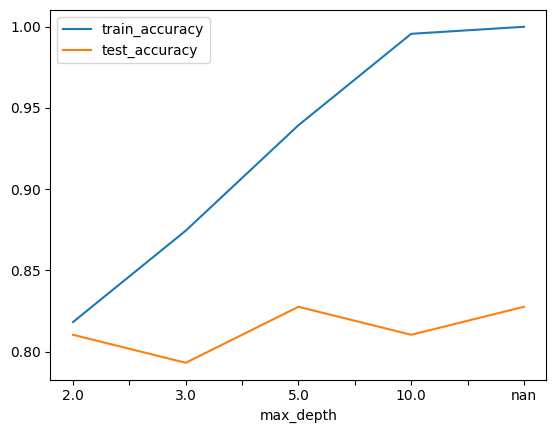

In [22]:
#3
#print(df_graph.info())
df_graph = pd.DataFrame(results)
print(df_graph.head())
df_graph['max_depth'] = df_graph['max_depth'].astype('str')
df_graph = df_graph.set_index('max_depth')
#print(df_graph.head())
df_graph.plot(y=['train_accuracy','test_accuracy'],kind='line')


*✏️ Your overfitting analysis here:*

At max_depth: 5 the model seems to be overfitted since training accuracy increases while test accuracy decreases (or diverges)


---
## Section 5: Model Pipeline & Deployment (10 pts)
*Estimated time: ~8 minutes*

---

### Q17 — Model Serialization with joblib (3 pts)

**Tasks:**
1. Take the **best-performing model** from Q15 (whichever had the highest test accuracy) (1 pt)
2. Save it to `"data/quiz_best_model.pkl"` using `joblib.dump()` (1 pt)
3. Load it back with `joblib.load()`, run predictions on `X_test`, and verify they match the original predictions using `np.array_equal()`. Print the result. (1 pt)

In [23]:
# Q17 — Your code here
import joblib

#1
model = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=5)
model.fit(X_train, y_train)

#2
joblib.dump(model, "data/quize_best_model.pkl")

#3
try: 
    load_model = joblib.load("data/quize_best_model.pkl")
except Exception as e:
    raise RuntimeError(f"Error loading model: {e}")

np.array_equal(model.predict(X_test), load_model.predict(X_test))



True

### Q18 — FastAPI Design (4 pts)

You want to deploy your heart disease model as a REST API using **FastAPI**.

**Tasks — answer in the markdown cell below (pseudocode/code is fine, it doesn't need to run):**

1. Write a **Pydantic `BaseModel`** class called `HeartFeatures` with all 13 feature fields from `heart.csv`, using appropriate types (`int` or `float`). (1 pt)
2. Write a `POST /predict` endpoint that: accepts `HeartFeatures`, converts it to a DataFrame, runs the model prediction, and returns `{"prediction": 0 or 1, "probability": float}`. (1 pt)
3. What **logging** would you add to this endpoint? List at least 3 log messages with their appropriate levels (DEBUG, INFO, WARNING, ERROR, CRITICAL). (1 pt)
4. What **error handling** would you add? Describe at least 2 scenarios that could go wrong and how you'd handle them. (1 pt)

In [24]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 231 entries, 93 to 102
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 231 non-null    int64  
 1   sex                 231 non-null    int64  
 2   cp                  231 non-null    int64  
 3   trtbps              231 non-null    int64  
 4   chol                231 non-null    int64  
 5   fbs                 231 non-null    int64  
 6   restecg             231 non-null    int64  
 7   thalachh            231 non-null    int64  
 8   exng                231 non-null    int64  
 9   oldpeak             231 non-null    float64
 10  slp                 231 non-null    int64  
 11  caa                 231 non-null    int64  
 12  thall               231 non-null    int64  
 13  normalized_thalach  231 non-null    float64
dtypes: float64(2), int64(12)
memory usage: 27.1 KB


*✏️ Your FastAPI design here:*
#1
```
class HeartFeatures(BaseModel):
    age: int
    sex: int
    cp: int
    trtbps: int
    chol: int
    fbs: int
    restecg: int
    thalachh: int
    oldpeak: float
    slp: int
    caa: int
    thall: int
```
#2
```
@app.post("/predict")
def predict_price(features: HeartFeatures):
    logging.info(f"Received features: {features}")
    try:
        # Convert the features to a DataFrame
        X = pd.DataFrame([features.dict()])
        logging.debug(f"X.shape: {X.shape}")

        # Make predictions
        predictions = model.predict(X)
        probabilities = model.predict_proba(X)
        logging.info(f"Predictions: {predictions})
        return {"prediction": predictions[0],"probability": probabilities}
    except Exception as e:
        logging.error(f"Error making prediction: {e}")
        return {"error": "An error occurred while making the prediction"}
```
#3
```
Debug log example
        logging.debug(f"X.shape: {X.shape}")

Info log example
    logging.info(f"Received features: {features}")

Error log example
    except Exception as e:
        logging.error(f"Error making prediction: {e}")

```
#4
- Loading Model Error -> return 504 
- Too many requests like Denial-of-Service (DoS) attack -> return 429 

### Q19 — Load Testing Design (3 pts)

You've deployed your heart disease API and need to verify it can handle traffic.

**Tasks — answer in the markdown cell below:**

1. What Python library/class would you use to send **500 concurrent requests**? (1 pt)
2. Write a function signature `run_load_test(num_requests: int)` and describe in pseudocode what it does (generate random data, send requests, collect results). (1 pt)
3. What **3 metrics** would you collect and report at the end of the load test? (1 pt)

*✏️ Your load testing design here:*

1. requests, concurrent.futures module
2. run_load_test(num_requests: int)
 - generate data on each requests
 - send request with generated data
 - check result and store result
 - finish test summarize result 
3. total time, error rate, average response time  

---
## Section 6: Boss Level — End-to-End Challenge (10 pts)
*Estimated time: ~8 minutes*

---

### Q20 — Full ML Pipeline (10 pts)

Using `social_df`, build a **complete ML pipeline** from scratch:

1. **Feature Engineering (2 pts):** Create at least **one new feature** (e.g., `Age_Salary_Ratio = Age / EstimatedSalary`, or binning Age into groups, or any creative transformation). Use both `Age` and `EstimatedSalary` plus your new feature(s) as inputs.

2. **Model Training (2 pts):** Train a `GradientBoostingClassifier` on your features.

3. **Threshold Optimization (2 pts):** Using `predict_proba`, find the threshold that maximizes the **F1 score** (hint: F1 = 2 * precision * recall / (precision + recall)). Print the optimal threshold and the F1 at that threshold.

4. **Final Evaluation (2 pts):** Apply your optimal threshold to the test set predictions. Print the `classification_report` at your chosen threshold.

5. **Save & Report (2 pts):**
   - Save the model to `"data/quiz_boss_model.pkl"` using joblib
   - In a markdown cell below, write a **3-sentence model report** explaining: what features you used, what threshold you chose and why, and how the model performed.

In [25]:
# Q20 — Your code here
#1
import numpy as np
from sklearn.metrics import precision_recall_curve
#print(social_df.info())
social_df['Age_Salary_Ratio'] = social_df['Age'] / social_df['EstimatedSalary']
social_df.head()

X = social_df[['Age','EstimatedSalary','Age_Salary_Ratio']]
y = social_df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2
gb_model = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_model.fit(X_train, y_train)

#3
y_test_pred = gb_model.predict(X_test)
y_test_proba = gb_model.predict_proba(X_test)
#print(y_test_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba[:,1])
# Calculate F1-Score for all thresholds
f1_scores = (2 * recall * precision) / (recall + precision)
#print(f1_scores)
# Identify the optimal threshold
idx = np.argmax(f1_scores)
#print(idx)
best_threshold = thresholds[idx]
best_f1 = f1_scores[idx]
#print(best_f1)
print(f'Best Threshold: {best_threshold:.4f}')
print(f'Best F1-Score: {best_f1:.4f}')

optimized_threshold = (y_test_proba[:,1] >= best_threshold).astype('int') 
#print(optimized_threshold)

#4
print(f"""
Optimized Threshold classification_report <Best Threshold:{best_threshold:.4f}> 
{classification_report(y_test, optimized_threshold)}""")
print(f"""
Original classification_report
{classification_report(y_test, y_test_pred)}""")

Best Threshold: 0.3566
Best F1-Score: 0.9000

Optimized Threshold classification_report <Best Threshold:0.3566> 
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        52
           1       0.84      0.96      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80


Original classification_report
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        52
           1       0.83      0.89      0.86        28

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



In [26]:
#5
import joblib
joblib.dump(gb_model, "data/quiz_boss_model.pkl")

['data/quiz_boss_model.pkl']

*✏️ Your 3-sentence model report here:*
### Model Report
 - Features -> 'Age','EstimatedSalary','Age_Salary_Ratio'
 - Threshold -> 0.3566 since best optimized F1 Score 0.9000
 - Precision: 0.84, Recall: 0.96

---

## You're Done!

**Before submitting:**
1. **Restart the kernel** and **Run All Cells** — make sure everything runs without errors
2. Check that all markdown answers are filled in (search for `✏️`)
3. Save the notebook

**Good work!** 🎉